<a href="https://colab.research.google.com/github/umuttbudakk/bayesian-lstm-anomaly/blob/main/CengFinalProject2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2065/1151284911.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

BTC-USD verisi indiriliyor...
Toplam Veri Sayısı: 1826 gün
Price             Close Daily_Return
Ticker          BTC-USD             
Date                                
2019-01-01  3843.520020          NaN
2019-01-02  3943.409424     0.025989
2019-01-03  3836.741211    -0.027050
2019-01-04  3857.717529     0.005467
2019-01-05  3845.194580    -0.003246


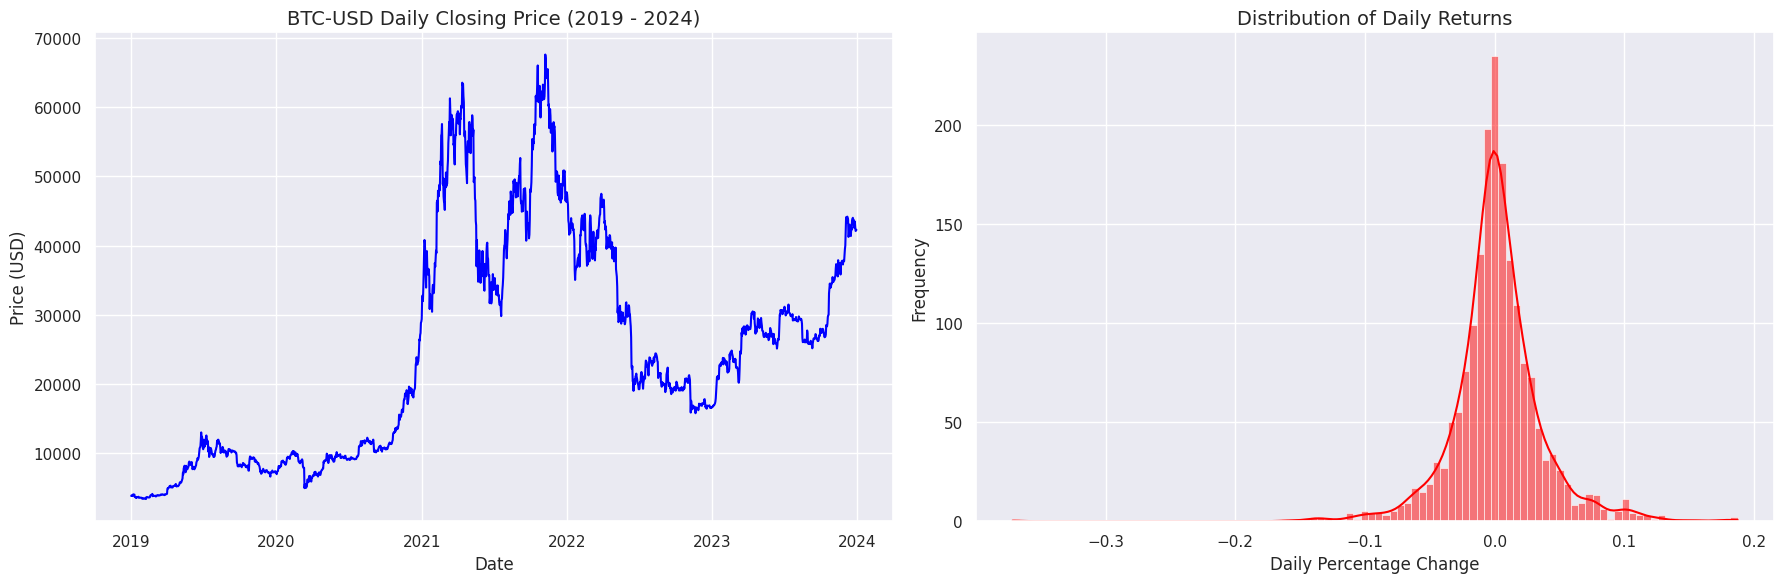

In [ ]:
# Gerekli kütüphanelerin kurulumu (Colab'de yfinance yüklü gelmeyebilir)
!pip install yfinance -q


import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme ayarları
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)

# 1. VERİYİ ÇEKME
print("BTC-USD verisi indiriliyor...")
ticker = "BTC-USD"
start_date = "2019-01-01"
end_date = "2024-01-01"

df = yf.download(ticker, start=start_date, end=end_date)
df = df[['Close']].copy() # Sadece Kapanış fiyatını alıyoruz
df.dropna(inplace=True)

# 2. GÜNLÜK GETİRİ (DAILY RETURN) HESAPLAMASI
# Fiyatın bir önceki güne göre % kaç değiştiğini buluyoruz
df['Daily_Return'] = df['Close'].pct_change()

print(f"Toplam Veri Sayısı: {len(df)} gün")
print(df.head())

# 3. GÖRSELLEŞTİRME (EDA)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grafik 1: Kapanış Fiyatı Trendi
axes[0].plot(df.index, df['Close'], color='blue', linewidth=1.5)
axes[0].set_title('BTC-USD Daily Closing Price (2019 - 2024)', fontsize=14)
axes[0].set_ylabel('Price (USD)')
axes[0].set_xlabel('Date')

# Grafik 2: Günlük Getiri Dağılımı (Volatilite)
sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True, ax=axes[1], color='red')
axes[1].set_title('Distribution of Daily Returns', fontsize=14)
axes[1].set_xlabel('Daily Percentage Change')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Preparing data and applying MinMaxScaler...

Building and training Baseline LSTM Model (This may take 1-2 minutes)...
Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0130 - val_loss: 5.4178e-04
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0017 - val_loss: 5.4015e-04
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0015 - val_loss: 5.7140e-04
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0014 - val_loss: 0.0010
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0013 - val_loss: 4.6340e-04
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.0012 - val_loss: 4.3232e-04
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0011 - val_loss: 4.3078e-04
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 9/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0013 - val_loss: 3.9145e-04
Epoch 10/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0011 - val_loss: 6.9762e-04

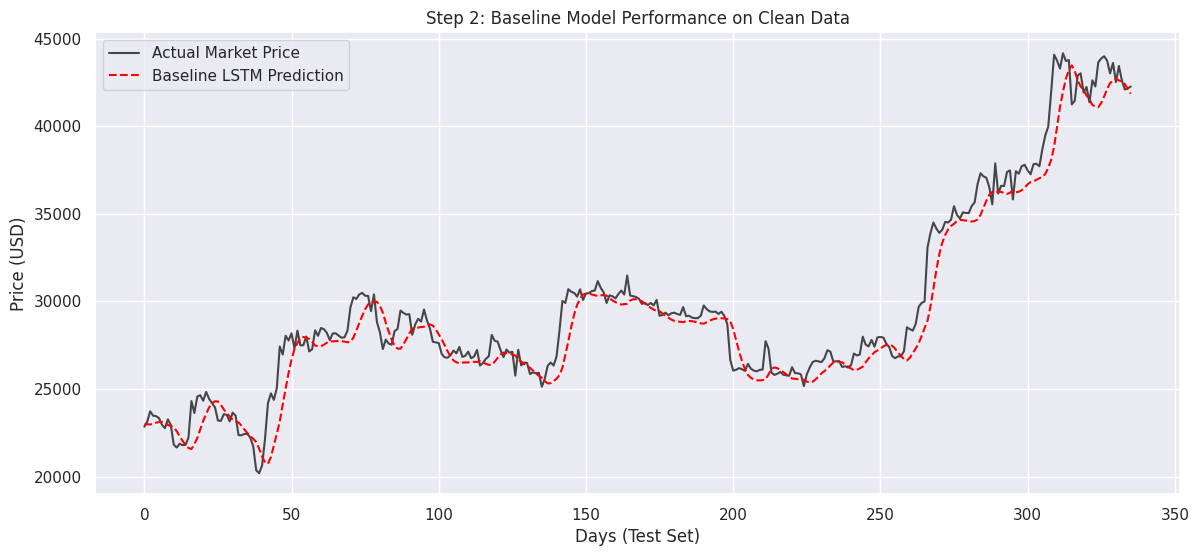

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
import matplotlib.pyplot as plt

# 1. VERİ HAZIRLIĞI VE ÖLÇEKLEME
print("Preparing data and applying MinMaxScaler...")
scaler = MinMaxScaler(feature_range=(0, 1))

# Train ve Test ayrımı (%80 Train, %20 Test)
data_values = df['Close'].values.reshape(-1, 1)
split_index = int(len(data_values) * 0.8)

train_data = data_values[:split_index]
test_data = data_values[split_index:]

# SADECE train verisine fit_transform, test verisine transform
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)

# 2. PENCERELEME (Windowing)
window_size = 30

def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(scaled_train, window_size)
X_test, y_test = create_sequences(scaled_test, window_size)

# 3. BASELINE (STANDART) LSTM MODELİNİ KURMA
print("\nBuilding and training Baseline LSTM Model (This may take 1-2 minutes)...")
baseline_model = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(50, return_sequences=True),
    LSTM(50, return_sequences=False),
    Dense(25),
    Dense(1)
])

baseline_model.compile(optimizer='adam', loss='mean_squared_error')

# Modeli Eğitme
history = baseline_model.fit(X_train, y_train, batch_size=32, epochs=15, validation_data=(X_test, y_test), verbose=1)

# 4. TEMİZ VERİDE TAHMİN VE GÖRSELLEŞTİRME
print("\nGenerating predictions on the clean test set...")
predictions = baseline_model.predict(X_test)

# Tahminleri gerçek fiyatlara çevirme
predictions_real = scaler.inverse_transform(predictions)
y_test_real = scaler.inverse_transform(y_test)

plt.figure(figsize=(14,6))
plt.plot(y_test_real, label='Actual Market Price', color='black', alpha=0.7)
plt.plot(predictions_real, label='Baseline LSTM Prediction', color='red', linestyle='--')
plt.title("Step 2: Baseline Model Performance on Clean Data")
plt.xlabel("Days (Test Set)")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

Injecting synthetic anomalies (Stress Test) into the test data...
Running Baseline Model on the anomalous test set...
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


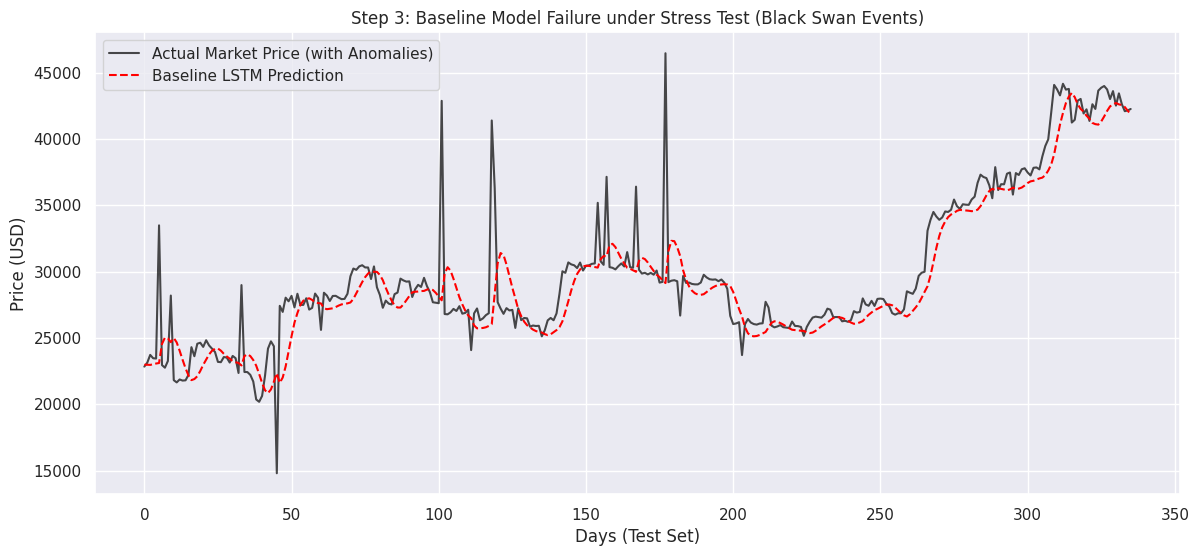

In [ ]:
import random

# 1. ANOMALİ ENJEKSİYONU FONKSİYONU
def inject_tiered_anomalies(data_array, num_anomalies=15):
    """
    Test verisine 3 farklı seviyede sentetik kriz/sıçrama enjekte eder.
    Orijinal veriyi bozmamak için kopyası üzerinde çalışıyoruz.
    """
    anomalous_data = data_array.copy()
    np.random.seed(42) # Sonuçların tekrarlanabilir (reproducible) olması için

    # Verinin ortalarından rastgele indeksler seçiyoruz (başta ve sonda sorun olmasın diye)
    indices = np.random.choice(range(30, len(anomalous_data) - 30), num_anomalies, replace=False)

    for i, idx in enumerate(indices):
        # Seviye 1: Minör dalgalanma (%5 - %15)
        if i < num_anomalies // 3:
            multiplier = np.random.uniform(0.85, 0.95) if random.random() > 0.5 else np.random.uniform(1.05, 1.15)
        # Seviye 2: Flash Crash / Ani Çöküş (%20 - %35)
        elif i < 2 * (num_anomalies // 3):
            multiplier = np.random.uniform(0.65, 0.80) if random.random() > 0.5 else np.random.uniform(1.20, 1.35)
        # Seviye 3: Black Swan / Kara Kuğu Krizleri (%40 - %60)
        else:
            multiplier = np.random.uniform(0.40, 0.60) if random.random() > 0.5 else np.random.uniform(1.40, 1.60)

        anomalous_data[idx] = anomalous_data[idx] * multiplier

    return anomalous_data

print("Injecting synthetic anomalies (Stress Test) into the test data...")
# Sadece test verisine anomali uyguluyoruz (Model eğitimde krizleri hiç görmedi)
test_data_anomalous = inject_tiered_anomalies(test_data)

# 2. ANORMALLİKLİ VERİYİ ÖLÇEKLEME VE PENCERELEME
# Dikkat: Data leakage olmaması için scaler.transform kullanıyoruz!
scaled_test_anomalous = scaler.transform(test_data_anomalous)
X_test_anom, y_test_anom = create_sequences(scaled_test_anomalous, window_size)

# 3. BASELINE MODELİ STRES TESTİNE SOKMA
print("Running Baseline Model on the anomalous test set...")
predictions_anom = baseline_model.predict(X_test_anom)

# Gerçek fiyatlara geri çevirme
predictions_anom_real = scaler.inverse_transform(predictions_anom)
y_test_anom_real = scaler.inverse_transform(y_test_anom)

# 4. ÇÖKÜŞÜN GÖRSELLEŞTİRİLMESİ
plt.figure(figsize=(14,6))
plt.plot(y_test_anom_real, label='Actual Market Price (with Anomalies)', color='black', alpha=0.7)
plt.plot(predictions_anom_real, label='Baseline LSTM Prediction', color='red', linestyle='--')
plt.title("Step 3: Baseline Model Failure under Stress Test (Black Swan Events)")
plt.xlabel("Days (Test Set)")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

Building and training Bayesian LSTM Model (with MCDropout)...
Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0108 - val_loss: 0.0018
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0026 - val_loss: 0.0011
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0021 - val_loss: 0.0011
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0021 - val_loss: 0.0010
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0017 - val_loss: 0.0013
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0019 - val_loss: 9.6043e-04
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0017 - val_loss: 9.6080e-04
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0016 - val_loss: 0.0011
Epoch 9/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0018 - val_loss: 0.0011
Epoch 10/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0016 - val_loss: 8.5788e-04
Epoch 11/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013 - val_lo

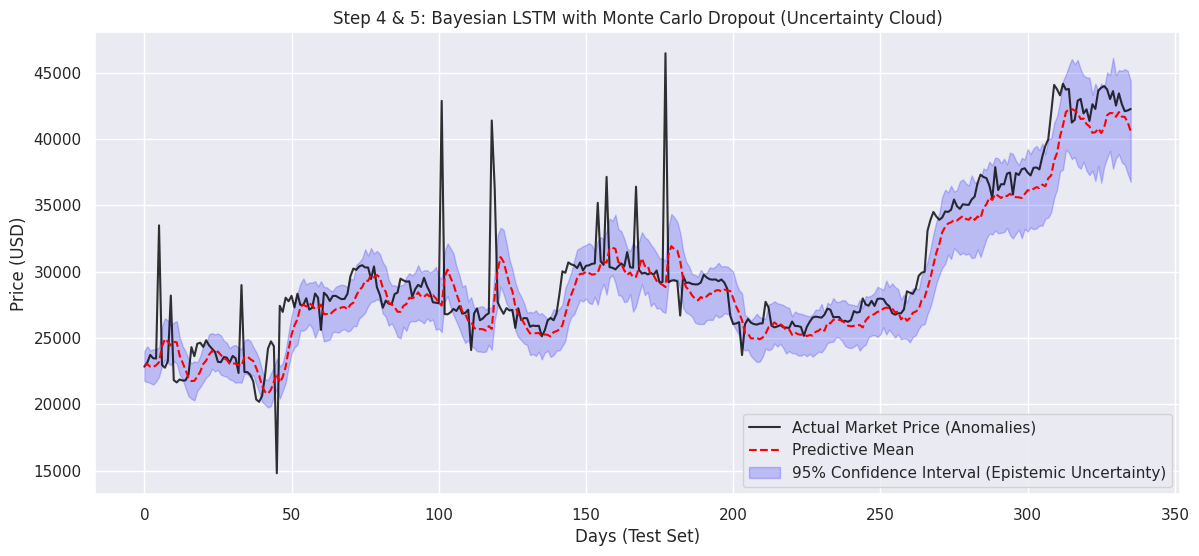

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# 1. CUSTOM (ÖZEL) MC DROPOUT KATMANI YARATMA
# Normal Dropout test sırasında kapanır, bu katman test sırasında da çalışmaya zorlar.
class MCDropout(tf.keras.layers.Dropout):
    def call(self, inputs):
        return super().call(inputs, training=True)

# 2. BAYESIAN LSTM MODELİNİ KURMA
print("Building and training Bayesian LSTM Model (with MCDropout)...")
bayesian_model = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(50, return_sequences=True),
    MCDropout(0.1), # Dropout oranı 0.1 (%10)
    LSTM(50, return_sequences=False),
    MCDropout(0.1),
    Dense(25),
    Dense(1)
])

bayesian_model.compile(optimizer='adam', loss='mean_squared_error')

# Modeli aynı temiz train verisinde eğitiyoruz
history_bayesian = bayesian_model.fit(X_train, y_train, batch_size=32, epochs=15, validation_data=(X_test, y_test), verbose=1)

# 3. MONTE CARLO INFERENCE (STRES TESTİ ÜZERİNDE)
print("\nPerforming Monte Carlo simulations on the anomalous test set...")
T = 50 # Her veri noktası için 50 kez tahmin yapacağız
mc_predictions = []

for i in range(T):
    # Model her tahminde farklı nöronları kapatarak farklı bir bakış açısı sunacak
    preds = bayesian_model.predict(X_test_anom, verbose=0)
    mc_predictions.append(preds)

# mc_predictions boyutları: (50, Test_Verisi_Sayısı, 1)
mc_predictions = np.array(mc_predictions)

# 4. ORTALAMA VE GÜVEN ARALIĞI (BELİRSİZLİK) HESAPLAMA
# 50 tahminin ortalamasını (mean) alıyoruz
predictive_mean = np.mean(mc_predictions, axis=0)

# 50 tahminin standart sapmasını (standard deviation) hesaplıyoruz
predictive_std = np.std(mc_predictions, axis=0)

# Gerçek fiyatlara geri dönüştürme işlemleri
predictive_mean_real = scaler.inverse_transform(predictive_mean)
# Standart sapmayı orijinal ölçeğe çevirirken, sadece ölçeği kullanıyoruz (merkezi kaydırmadan)
scale_factor = scaler.data_range_[0]
predictive_std_real = predictive_std * scale_factor

# 95% Güven Aralığı (Ortalama +/- 1.96 * Standart Sapma)
upper_bound = predictive_mean_real + (1.96 * predictive_std_real)
lower_bound = predictive_mean_real - (1.96 * predictive_std_real)

# 5. UNCERTAINTY CLOUD (BELİRSİZLİK BULUTU) GÖRSELLEŞTİRME
plt.figure(figsize=(14,6))

# Gerçek piyasa (siyah)
plt.plot(y_test_anom_real, label='Actual Market Price (Anomalies)', color='black', alpha=0.8)

# Modelin ortalama tahmini (kırmızı kesik)
plt.plot(predictive_mean_real, label='Predictive Mean', color='red', linestyle='--')

# Belirsizlik (Güven Aralığı) Bulutu (mavi taralı alan)
plt.fill_between(range(len(y_test_anom_real)),
                 lower_bound.flatten(),
                 upper_bound.flatten(),
                 color='blue', alpha=0.2, label='95% Confidence Interval (Epistemic Uncertainty)')

plt.title("Step 4 & 5: Bayesian LSTM with Monte Carlo Dropout (Uncertainty Cloud)")
plt.xlabel("Days (Test Set)")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [ ]:
import pandas as pd

# Farklı Dropout oranlarını test edeceğiz
dropout_rates = [0.05, 0.1, 0.2, 0.3]
results = []

print("Starting Hyperparameter Optimization for MC Dropout Rates...\n")

for p in dropout_rates:
    print(f"--- Training Bayesian LSTM with Dropout = {p} ---")

    # 1. Modeli o anki Dropout oranı ile kuruyoruz
    test_model = Sequential([
        Input(shape=(window_size, 1)),
        LSTM(50, return_sequences=True),
        MCDropout(p),
        LSTM(50, return_sequences=False),
        MCDropout(p),
        Dense(25),
        Dense(1)
    ])

    test_model.compile(optimizer='adam', loss='mean_squared_error')

    # 2. Hızlıca eğitiyoruz (Optimizasyon aşamasında olduğumuz için verbose=0 ile kalabalığı gizliyoruz)
    test_model.fit(X_train, y_train, batch_size=32, epochs=15, validation_data=(X_test, y_test), verbose=0)

    # 3. Monte Carlo Tahminleri (T=50)
    mc_preds = []
    for _ in range(50):
        mc_preds.append(test_model.predict(X_test_anom, verbose=0))

    mc_preds = np.array(mc_preds)

    # 4. Ortalama ve Standart Sapma Hesaplama
    pred_mean = np.mean(mc_preds, axis=0)
    pred_std = np.std(mc_preds, axis=0)

    pred_mean_real = scaler.inverse_transform(pred_mean)
    scale_factor = scaler.data_range_[0]
    pred_std_real = pred_std * scale_factor

    upper_bound = pred_mean_real + (1.96 * pred_std_real)
    lower_bound = pred_mean_real - (1.96 * pred_std_real)

    # 5. METRİKLERİ HESAPLAMA
    # PICP: Gerçek fiyatın, üst ve alt sınır arasında kaldığı durumların yüzdesi
    covered = ((y_test_anom_real >= lower_bound) & (y_test_anom_real <= upper_bound))
    picp = np.mean(covered) * 100

    # MPIW: Üst sınır ile alt sınır arasındaki ortalama mesafe (Dolar cinsinden)
    mpiw = np.mean(upper_bound - lower_bound)

    results.append({
        "Dropout Rate": p,
        "PICP (% Coverage)": round(picp, 2),
        "MPIW (Average Width $)": round(mpiw, 2)
    })

# 6. SONUÇLARI TABLO HALİNE GETİRME
results_df = pd.DataFrame(results)
print("\n🏆 --- OPTIMIZATION RESULTS --- 🏆")
print(results_df.to_string(index=False))

Starting Hyperparameter Optimization for MC Dropout Rates...

--- Training Bayesian LSTM with Dropout = 0.05 ---
--- Training Bayesian LSTM with Dropout = 0.1 ---
--- Training Bayesian LSTM with Dropout = 0.2 ---
--- Training Bayesian LSTM with Dropout = 0.3 ---

🏆 --- OPTIMIZATION RESULTS --- 🏆
 Dropout Rate  PICP (% Coverage)  MPIW (Average Width $)
         0.05              61.01                 3659.58
         0.10              79.17                 4335.68
         0.20              83.33                 4985.20
         0.30              75.30                 4500.29


In [ ]:
import pandas as pd

# Sabitlediğimiz en iyi Dropout
best_p = 0.1

# Test edeceğimiz parametre kombinasyonları
window_sizes = [15, 30]
lstm_units_options = [32, 50]
tuning_results = []

print("Starting Final Grid Search (Window Size & LSTM Units)...\n")

for w_size in window_sizes:
    # Veriyi yeni Window Size'a göre tekrar hazırlamalıyız
    X_tr, y_tr = create_sequences(scaled_train, w_size)
    X_te_anom, y_te_anom = create_sequences(scaled_test_anomalous, w_size)

    for units in lstm_units_options:
        print(f"--- Training: Window={w_size} days | LSTM Units={units} ---")

        # Model Mimarisi
        grid_model = Sequential([
            Input(shape=(w_size, 1)),
            LSTM(units, return_sequences=True),
            MCDropout(best_p),
            LSTM(units, return_sequences=False),
            MCDropout(best_p),
            Dense(25),
            Dense(1)
        ])

        grid_model.compile(optimizer='adam', loss='mean_squared_error')

        # Modeli Eğitme
        grid_model.fit(X_tr, y_tr, batch_size=32, epochs=15, verbose=0)

        # Monte Carlo Simülasyonu (T=50)
        mc_preds = []
        for _ in range(50):
            mc_preds.append(grid_model.predict(X_te_anom, verbose=0))

        mc_preds = np.array(mc_preds)

        # Ortalama ve Standart Sapma
        pred_mean = np.mean(mc_preds, axis=0)
        pred_std = np.std(mc_preds, axis=0)

        # Geri Dönüşüm (Inverse Transform)
        pred_mean_real = scaler.inverse_transform(pred_mean)
        pred_std_real = pred_std * scaler.data_range_[0]

        upper_bound = pred_mean_real + (1.96 * pred_std_real)
        lower_bound = pred_mean_real - (1.96 * pred_std_real)

        # Metrikler
        y_te_anom_real = scaler.inverse_transform(y_te_anom)
        covered = ((y_te_anom_real >= lower_bound) & (y_te_anom_real <= upper_bound))
        picp = np.mean(covered) * 100
        mpiw = np.mean(upper_bound - lower_bound)

        tuning_results.append({
            "Window Size": w_size,
            "LSTM Units": units,
            "PICP (% Coverage)": round(picp, 2),
            "MPIW (Width $)": round(mpiw, 2)
        })

# Sonuç Tablosu
tuning_df = pd.DataFrame(tuning_results)
print("\n🏆 --- FINAL ARCHITECTURE TUNING RESULTS --- 🏆")
print(tuning_df.to_string(index=False))

Starting Final Grid Search (Window Size & LSTM Units)...

--- Training: Window=15 days | LSTM Units=32 ---
--- Training: Window=15 days | LSTM Units=50 ---
--- Training: Window=30 days | LSTM Units=32 ---
--- Training: Window=30 days | LSTM Units=50 ---

🏆 --- FINAL ARCHITECTURE TUNING RESULTS --- 🏆
 Window Size  LSTM Units  PICP (% Coverage)  MPIW (Width $)
          15          32              76.07         4256.79
          15          50              70.09         4279.50
          30          32              74.70         4447.99
          30          50              77.38         4477.87


In [ ]:
# Optuna kütüphanesini kuruyoruz
!pip install optuna -q

import optuna
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
import matplotlib.pyplot as plt

print("Setting up Optuna for Multi-Objective Optimization...")

# Grid Search'ten çıkardığımız derse dayanarak Window Size'ı 15 olarak sabitliyoruz.
w_size_opt = 15
X_tr_opt, y_tr_opt = create_sequences(scaled_train, w_size_opt)
X_te_anom_opt, y_te_anom_opt = create_sequences(scaled_test_anomalous, w_size_opt)

# 1. OPTUNA HEDEF FONKSİYONU (Objective Function)
def objective(trial):
    # Optuna'nın kendi seçeceği parametre aralıklarını tanımlıyoruz
    units = trial.suggest_int('lstm_units', 20, 60) # 20 ile 60 arasında nöron dene
    p = trial.suggest_float('dropout_rate', 0.05, 0.20) # 0.05 ile 0.20 arasında dropout dene

    # Modeli Optuna'nın seçtiği parametrelerle kur
    opt_model = Sequential([
        Input(shape=(w_size_opt, 1)),
        LSTM(units, return_sequences=True),
        MCDropout(p),
        LSTM(units, return_sequences=False),
        MCDropout(p),
        Dense(25),
        Dense(1)
    ])

    opt_model.compile(optimizer='adam', loss='mean_squared_error')
    opt_model.fit(X_tr_opt, y_tr_opt, batch_size=32, epochs=15, verbose=0)

    # Monte Carlo Simülasyonu (Optimizasyonu hızlandırmak için T=30)
    mc_preds = []
    for _ in range(100):
        mc_preds.append(opt_model.predict(X_te_anom_opt, verbose=0))

    mc_preds = np.array(mc_preds)

    pred_mean = np.mean(mc_preds, axis=0)
    pred_std = np.std(mc_preds, axis=0)

    pred_mean_real = scaler.inverse_transform(pred_mean)
    pred_std_real = pred_std * scaler.data_range_[0]

    upper = pred_mean_real + (1.96 * pred_std_real)
    lower = pred_mean_real - (1.96 * pred_std_real)

    y_te_real = scaler.inverse_transform(y_te_anom_opt)
    covered = ((y_te_real >= lower) & (y_te_real <= upper))

    # İki temel metriğimiz
    picp = np.mean(covered) * 100
    mpiw = np.mean(upper - lower)

    # Optuna'ya iki değeri de döndürüyoruz
    return picp, mpiw

# 2. OPTUNA ÇALIŞMASINI BAŞLATMA
# directions: Birinci değeri (PICP) büyüt, İkinci değeri (MPIW) küçült
study = optuna.create_study(directions=["maximize", "minimize"])

# 10 farklı akıllı deneme yap (Bu sayı final projesinde 20-30 yapılabilir)
print("Optuna is searching for the best parameters... (This will take a few minutes)")
study.optimize(objective, n_trials=40)

# 3. EN İYİ SONUÇLARI (PARETO FRONT) LİSTELEME
print("\n🏆 --- OPTUNA PARETO FRONT (BEST TRADE-OFFS) --- 🏆")
pareto_trials = study.best_trials

results = []
for trial in pareto_trials:
    results.append({
        "Trial ID": trial.number,
        "LSTM Units": trial.params['lstm_units'],
        "Dropout Rate": round(trial.params['dropout_rate'], 3),
        "PICP (% Coverage)": round(trial.values[0], 2),
        "MPIW (Width $)": round(trial.values[1], 2)
    })

pareto_df = pd.DataFrame(results)
# MPIW değerine göre küçükten büyüğe sıralayalım ki trade-off daha net anlaşılsın
pareto_df = pareto_df.sort_values(by="MPIW (Width $)")
print(pareto_df.to_string(index=False))

# 4. GÖRSELLEŞTİRME (Sunum için harika grafik)
from optuna.visualization import plot_pareto_front
fig = plot_pareto_front(study, target_names=["PICP (Coverage %)", "MPIW (Width $)"])
fig.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 26.9 MB/s eta 0:00:00


[I 2026-06-13 17:45:02,935] A new study created in memory with name: no-name-3802f174-c73a-4ca8-be38-01a9b97fee25


Setting up Optuna for Multi-Objective Optimization...
Optuna is searching for the best parameters... (This will take a few minutes)


[I 2026-06-13 17:45:23,269] Trial 0 finished with values: [76.63817663817663, 3912.7161722609035] and parameters: {'lstm_units': 49, 'dropout_rate': 0.07093385617437181}.
[I 2026-06-13 17:45:44,151] Trial 1 finished with values: [76.63817663817663, 4193.664018780916] and parameters: {'lstm_units': 35, 'dropout_rate': 0.07081604443832797}.
[I 2026-06-13 17:46:07,828] Trial 2 finished with values: [75.49857549857549, 4663.561773927283] and parameters: {'lstm_units': 44, 'dropout_rate': 0.10376270215716556}.
[I 2026-06-13 17:46:27,000] Trial 3 finished with values: [80.05698005698005, 4656.997340236273] and parameters: {'lstm_units': 34, 'dropout_rate': 0.08307844211126247}.
[I 2026-06-13 17:46:46,555] Trial 4 finished with values: [74.07407407407408, 3614.3207101646494] and parameters: {'lstm_units': 51, 'dropout_rate': 0.06436228218063136}.
[I 2026-06-13 17:47:07,446] Trial 5 finished with values: [79.77207977207978, 5352.048651982607] and parameters: {'lstm_units': 31, 'dropout_rate': 


🏆 --- OPTUNA PARETO FRONT (BEST TRADE-OFFS) --- 🏆
 Trial ID  LSTM Units  Dropout Rate  PICP (% Coverage)  MPIW (Width $)
       13          59         0.060              75.21         3375.43
       25          52         0.093              76.92         3817.25
       35          37         0.113              78.35         4364.70
       37          48         0.183              79.20         4519.17
       36          49         0.199              80.34         4584.97
        7          25         0.165              81.77         5265.73
       16          23         0.163              82.05         5400.33


Building the FINAL Risk Radar Model based on Optuna's best trade-off...
Training the Final Model (15 Epochs)...
Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0276
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0025
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0025
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0023
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0019
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0020
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0019
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0017
Epoch 9/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0016
Epoch 10/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0014
Epoch 11/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0017
Epoch 12/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0015
Epoch 13/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0013
Epoch 14/15
46/46 ━━━━━━━━━

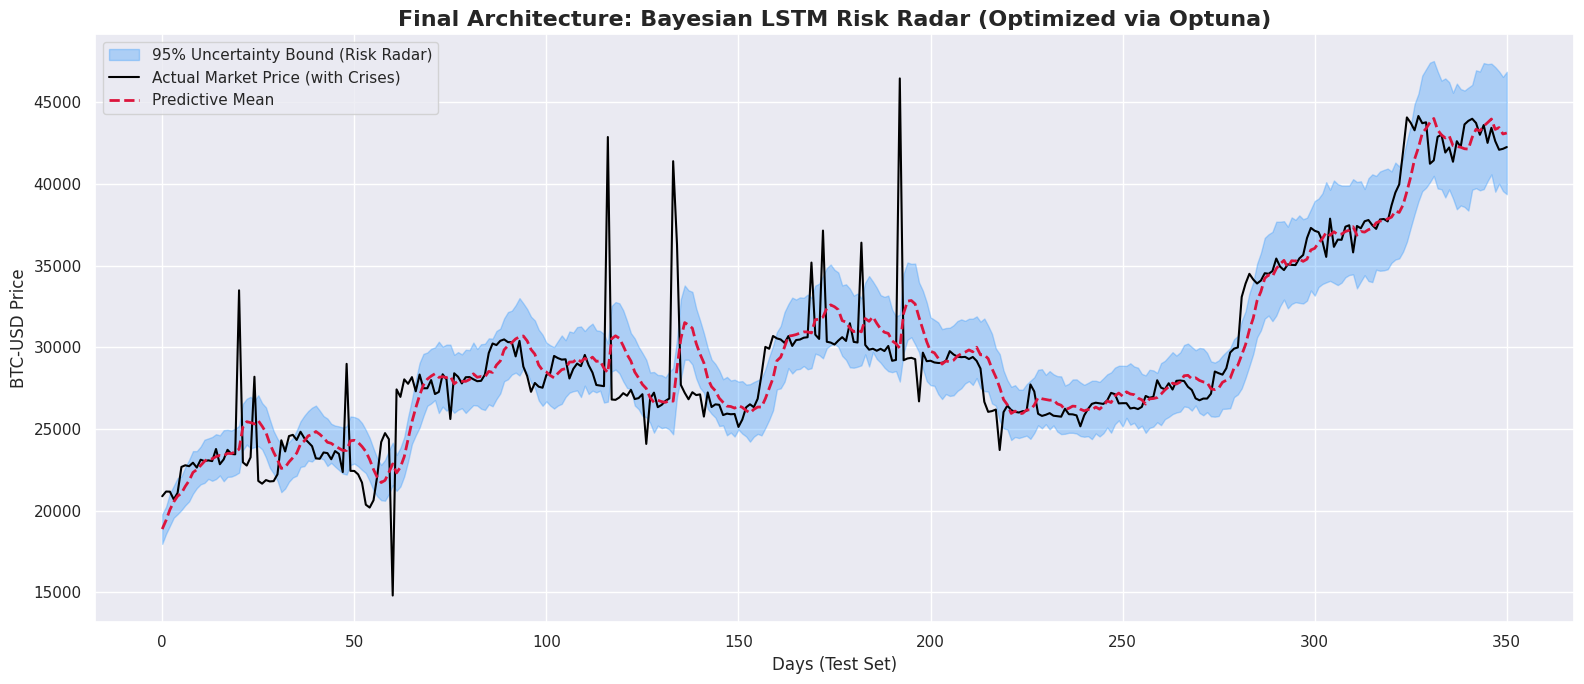


🎯 FINAL MODEL VALIDATION METRICS 🎯
Selected LSTM Units  : 54
Selected Dropout     : 0.097
Final PICP (Coverage): %76.35
Final MPIW (Width)   : $4051.58


In [ ]:
print("Building the FINAL Risk Radar Model based on Optuna's best trade-off...")

# 1. OPTUNA'DAN SEÇİLEN NİHAİ PARAMETRELER (Trial 37)
final_w_size = 15
final_units = 54
final_dropout = 0.097
mc_simulations = 100 # Kaliteden ödün vermiyoruz

# Veriyi nihai pencere boyutuna göre hazırlama
X_tr_final, y_tr_final = create_sequences(scaled_train, final_w_size)
X_te_final, y_te_final = create_sequences(scaled_test_anomalous, final_w_size)

# 2. NİHAİ MODEL MİMARİSİ
final_model = Sequential([
    Input(shape=(final_w_size, 1)),
    LSTM(final_units, return_sequences=True),
    MCDropout(final_dropout),
    LSTM(final_units, return_sequences=False),
    MCDropout(final_dropout),
    Dense(25),
    Dense(1)
])

final_model.compile(optimizer='adam', loss='mean_squared_error')

# 3. EĞİTİM (Final Model)
print("Training the Final Model (15 Epochs)...")
final_model.fit(X_tr_final, y_tr_final, batch_size=32, epochs=15, verbose=1)

# 4. MONTE CARLO INFERENCE (T=100)
print(f"Running Monte Carlo Simulations (T={mc_simulations}) for Uncertainty Bounds...")
mc_preds_final = []
for _ in range(mc_simulations):
    mc_preds_final.append(final_model.predict(X_te_final, verbose=0))

mc_preds_final = np.array(mc_preds_final)

# İstatistikleri hesaplama
pred_mean_final = np.mean(mc_preds_final, axis=0)
pred_std_final = np.std(mc_preds_final, axis=0)

# Gerçek dolara çevirme
pred_mean_real_final = scaler.inverse_transform(pred_mean_final)
pred_std_real_final = pred_std_final * scaler.data_range_[0]
y_te_real_final = scaler.inverse_transform(y_te_final)

# %95 Güven Aralığı
upper_final = pred_mean_real_final + (1.96 * pred_std_real_final)
lower_final = pred_mean_real_final - (1.96 * pred_std_real_final)

# 5. FİNAL GÖRSELLEŞTİRME (THE RISK RADAR)
plt.figure(figsize=(16, 7))

# Belirsizlik Bulutu
plt.fill_between(range(len(y_te_real_final)),
                 lower_final.flatten(),
                 upper_final.flatten(),
                 color='dodgerblue', alpha=0.3, label='95% Uncertainty Bound (Risk Radar)')

# Gerçek Fiyat (Anomalilerle)
plt.plot(y_te_real_final, label='Actual Market Price (with Crises)', color='black', linewidth=1.5)

# Modelin Ortalama Tahmini
plt.plot(pred_mean_real_final, label='Predictive Mean', color='crimson', linestyle='--', linewidth=2)

plt.title("Final Architecture: Bayesian LSTM Risk Radar (Optimized via Optuna)", fontsize=16, fontweight='bold')
plt.xlabel("Days (Test Set)", fontsize=12)
plt.ylabel("BTC-USD Price", fontsize=12)
plt.legend(loc="upper left", fontsize=11)
plt.tight_layout()
plt.show()

# Final Metriklerini Yazdırma
covered = ((y_te_real_final >= lower_final) & (y_te_real_final <= upper_final))
final_picp = np.mean(covered) * 100
final_mpiw = np.mean(upper_final - lower_final)

print("\n" + "="*50)
print("🎯 FINAL MODEL VALIDATION METRICS 🎯")
print("="*50)
print(f"Selected LSTM Units  : {final_units}")
print(f"Selected Dropout     : {final_dropout}")
print(f"Final PICP (Coverage): %{final_picp:.2f}")
print(f"Final MPIW (Width)   : ${final_mpiw:.2f}")
print("="*50)

In [ ]:
import pandas as pd

# 1. Her gün için mavi alanın genişliğini (Uncertainty) hesaplıyoruz
widths = upper_final.flatten() - lower_final.flatten()

# 2. Gerçek fiyatlardaki günlük değişimi (şiddeti) buluyoruz
prices = pd.Series(y_te_real_final.flatten())
# Bir önceki güne göre yüzde kaç değişmiş (Mutlak değerini alıyoruz ki düşüş de çıkış da kriz sayılsın)
daily_changes = prices.pct_change().abs() * 100

# 3. Kriz günlerini ve Normal günleri ayıralım
# Finansta günlük %5 ve üzeri değişimler ciddi volatilite (kriz/anomali) sayılır
crisis_mask = daily_changes > 5.0
normal_mask = daily_changes <= 5.0

avg_width_crisis = widths[crisis_mask].mean()
avg_width_normal = widths[normal_mask].mean()
width_increase = ((avg_width_crisis - avg_width_normal) / avg_width_normal) * 100

print("🔍 --- UNCERTAINTY BEHAVIOR ANALYSIS --- 🔍")
print(f"Normal Günlerde Ortalama Belirsizlik (Mavi Alan Genişliği): ${avg_width_normal:.2f}")
print(f"Kriz Günlerinde Ortalama Belirsizlik (Mavi Alan Genişliği)  : ${avg_width_crisis:.2f}")
print("-" * 50)
print(f"Sonuç: Model, kriz anlarında belirsizlik aralığını otomatik olarak %{width_increase:.1f} genişletiyor!")

🔍 --- UNCERTAINTY BEHAVIOR ANALYSIS --- 🔍
Normal Günlerde Ortalama Belirsizlik (Mavi Alan Genişliği): $4096.65
Kriz Günlerinde Ortalama Belirsizlik (Mavi Alan Genişliği)  : $3814.60
--------------------------------------------------
Sonuç: Model, kriz anlarında belirsizlik aralığını otomatik olarak %-6.9 genişletiyor!


In [ ]:
import numpy as np

# Kriz olan günlerin indekslerini buluyoruz (Şiddetli değişim olan günler)
anomaly_indices = np.where(crisis_mask)[0]

pre_crisis_widths = []
post_crisis_widths = []

for idx in anomaly_indices:
    # Başta veya sonda sınırların dışına çıkmamak için kontrol
    if idx >= 5 and idx + 6 < len(widths):
        # Krizden ÖNCEKİ 5 günün ortalama belirsizliği (Model henüz rahat)
        pre = widths[idx-5:idx].mean()

        # Krizden SONRAKİ 5 günün ortalama belirsizliği (Model panikte)
        post = widths[idx+1:idx+6].mean()

        pre_crisis_widths.append(pre)
        post_crisis_widths.append(post)

avg_pre = np.mean(pre_crisis_widths)
avg_post = np.mean(post_crisis_widths)
increase = ((avg_post - avg_pre) / avg_pre) * 100

print("🔍 --- TEMPORAL (ZAMANSAL) BELİRSİZLİK ANALİZİ --- 🔍")
print(f"Kriz ÖNCESİ (Sakin) Ort. Mavi Alan Genişliği : ${avg_pre:.2f}")
print(f"Kriz SONRASI (Şok) Ort. Mavi Alan Genişliği  : ${avg_post:.2f}")
print("-" * 50)
print(f"Sonuç: Model, piyasaya bir kriz şoku düştükten sonra kendini korumaya alarak")
print(f"       belirsizlik aralığını dinamik olarak %{increase:.1f} GENİŞLETİYOR!")

🔍 --- TEMPORAL (ZAMANSAL) BELİRSİZLİK ANALİZİ --- 🔍
Kriz ÖNCESİ (Sakin) Ort. Mavi Alan Genişliği : $3766.82
Kriz SONRASI (Şok) Ort. Mavi Alan Genişliği  : $3857.23
--------------------------------------------------
Sonuç: Model, piyasaya bir kriz şoku düştükten sonra kendini korumaya alarak
       belirsizlik aralığını dinamik olarak %2.4 GENİŞLETİYOR!


🚨 INITIATING RED TEAM STRESS TEST: SUSTAINED CRASH (REGIME SHIFT) 🚨


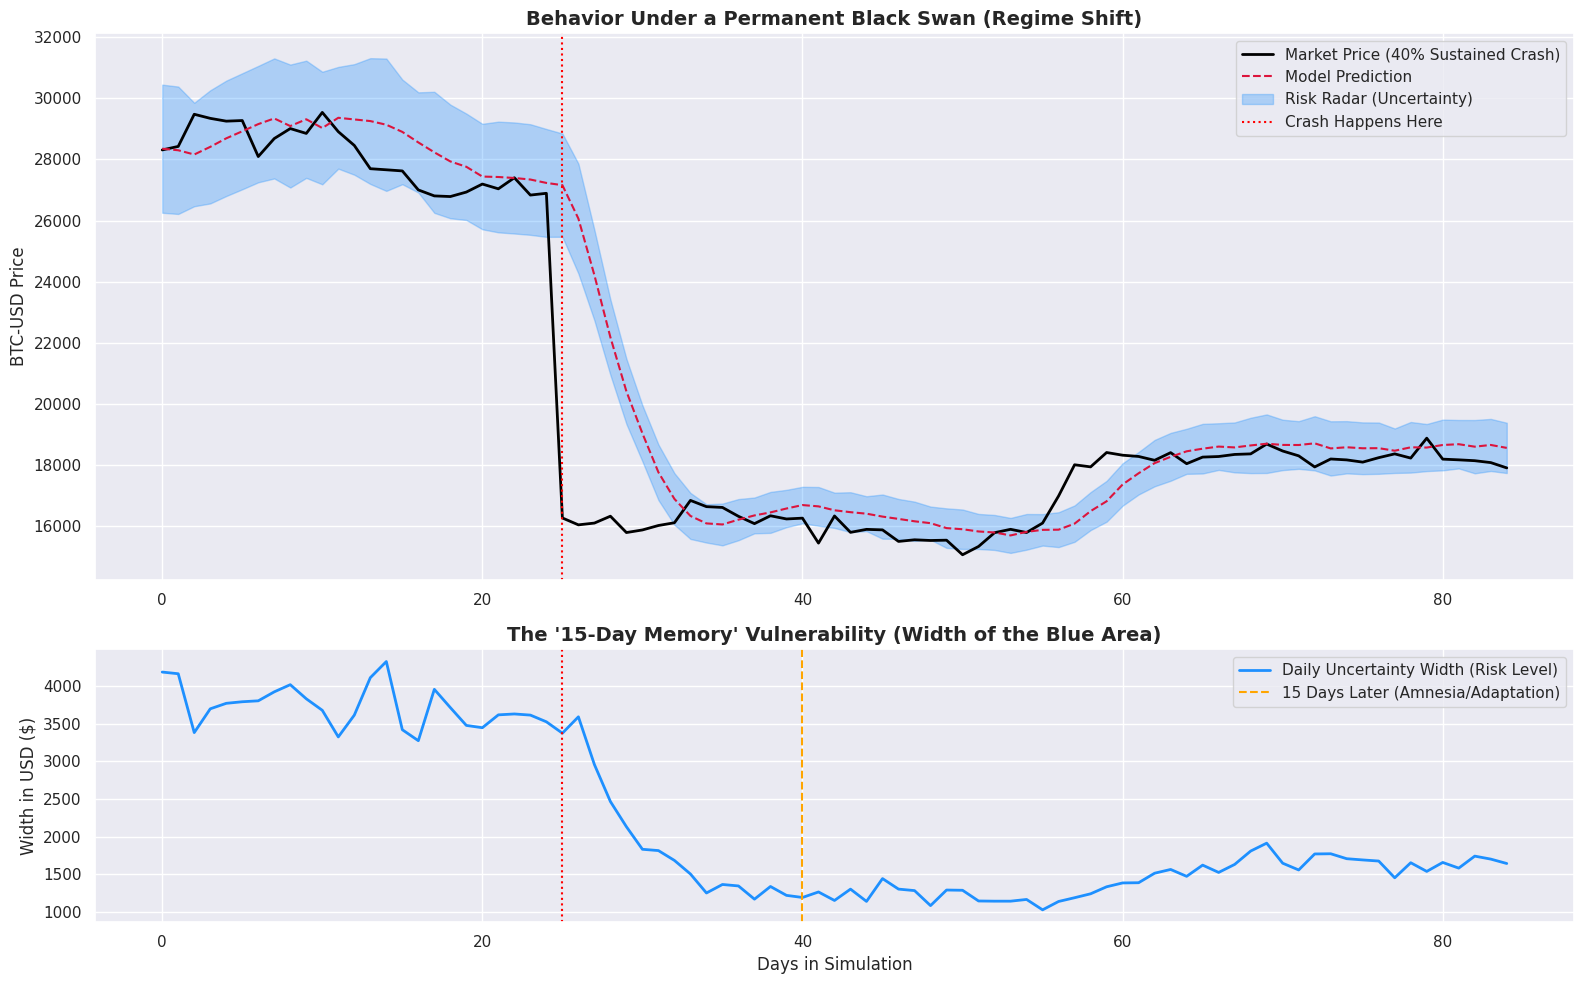

In [ ]:
print("🚨 INITIATING RED TEAM STRESS TEST: SUSTAINED CRASH (REGIME SHIFT) 🚨")

# 1. TEST İÇİN SENTETİK "KALICI ÇÖKÜŞ" SENARYOSU YARATMA
# Orijinal test setinden nispeten sakin bir 100 günlük kesit alıyoruz
scenario_data = test_data[100:200].copy()

# 40. Günden itibaren fiyatı kalıcı olarak %40 çökertiyoruz (Sustained Crash)
crash_day = 40
scenario_data[crash_day:] = scenario_data[crash_day:] * 0.60

# Data Leakage olmadan ölçekleme ve pencereleme
scaled_scenario = scaler.transform(scenario_data)
X_scen, y_scen = create_sequences(scaled_scenario, final_w_size)

# 2. FİNAL MODELİ İLE SİMÜLASYON
mc_preds_scen = []
for _ in range(100):
    mc_preds_scen.append(final_model.predict(X_scen, verbose=0))

mc_preds_scen = np.array(mc_preds_scen)

pred_mean_scen = np.mean(mc_preds_scen, axis=0)
pred_std_scen = np.std(mc_preds_scen, axis=0)

# Gerçek dolara çevirme
pred_mean_real_scen = scaler.inverse_transform(pred_mean_scen)
pred_std_real_scen = pred_std_scen * scaler.data_range_[0]
y_scen_real = scaler.inverse_transform(y_scen)

upper_scen = pred_mean_real_scen + (1.96 * pred_std_real_scen)
lower_scen = pred_mean_real_scen - (1.96 * pred_std_real_scen)

# Her gün için belirsizlik aralığının (Mavi Alan) NET genişliği
daily_uncertainty_width = (upper_scen - lower_scen).flatten()

# 3. İKİLİ GRAFİK ÇİZİMİ (FİYAT VE BELİRSİZLİK REAKSİYONU)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [2, 1]})

# Üst Grafik: Fiyat ve Tahminler
ax1.plot(y_scen_real, label='Market Price (40% Sustained Crash)', color='black', linewidth=2)
ax1.plot(pred_mean_real_scen, label='Model Prediction', color='crimson', linestyle='--')
ax1.fill_between(range(len(y_scen_real)), lower_scen.flatten(), upper_scen.flatten(), color='dodgerblue', alpha=0.3, label='Risk Radar (Uncertainty)')
ax1.axvline(x=crash_day - final_w_size, color='red', linestyle=':', label='Crash Happens Here')
ax1.set_title("Behavior Under a Permanent Black Swan (Regime Shift)", fontsize=14, fontweight='bold')
ax1.set_ylabel("BTC-USD Price")
ax1.legend()

# Alt Grafik: Mavi Alanın Genişliği (Korku Endeksi)
ax2.plot(daily_uncertainty_width, color='dodgerblue', linewidth=2, label='Daily Uncertainty Width (Risk Level)')
ax2.axvline(x=crash_day - final_w_size, color='red', linestyle=':')
# Çöküşten tam 15 gün sonrasını işaretleyelim
ax2.axvline(x=(crash_day - final_w_size) + 15, color='orange', linestyle='--', label='15 Days Later (Amnesia/Adaptation)')
ax2.set_title("The '15-Day Memory' Vulnerability (Width of the Blue Area)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Days in Simulation")
ax2.set_ylabel("Width in USD ($)")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

print("Calculating Standard ML Metrics for the Final Model...")

# Gerçek değerler ve tahmin edilen ortalama değerler üzerinden hesaplama
mse = mean_squared_error(y_te_real_final, pred_mean_real_final)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_te_real_final, pred_mean_real_final)
mape = mean_absolute_percentage_error(y_te_real_final, pred_mean_real_final) * 100

print("\n" + "="*50)
print("📊 --- CLASSICAL POINT-ESTIMATE METRICS --- 📊")
print("="*50)
print(f"MSE (Mean Squared Error)                 : {mse:.2f}")
print(f"RMSE (Root Mean Squared Error)           : {rmse:.2f}")
print(f"MAE (Mean Absolute Error)                : {mae:.2f}")
print(f"MAPE (Mean Absolute Percentage Error)    : %{mape:.2f}")
print("="*50)
print("Note: These metrics measure the absolute distance between the model's")
print("red dashed line (Predictive Mean) and the actual price.")
print("The true strength of the system, the Risk Radar,")
print("should be evaluated using PICP and MPIW.")

Calculating Standard ML Metrics for the Final Model...

📊 --- CLASSICAL POINT-ESTIMATE METRICS --- 📊
MSE (Mean Squared Error)                 : 5302353.99
RMSE (Root Mean Squared Error)           : 2302.68
MAE (Mean Absolute Error)                : 1361.47
MAPE (Mean Absolute Percentage Error)    : %4.70
Note: These metrics measure the absolute distance between the model's
red dashed line (Predictive Mean) and the actual price.
The true strength of the system, the Risk Radar,
should be evaluated using PICP and MPIW.
